# Chapter 3: Classification
<t>
<h3><i>MNIST</i></h3>

In [91]:
# importing the dataset
from sklearn.datasets import fetch_openml
plt.style.use("ggplot")
mnist = fetch_openml("mnist_784", as_frame=False)
mnist

{'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 'target': array(['5', '0', '4', ..., '4', '5', '6'], dtype=object),
 'frame': None,
 'categories': {'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']},
 'feature_names': ['pixel1',
  'pixel2',
  'pixel3',
  'pixel4',
  'pixel5',
  'pixel6',
  'pixel7',
  'pixel8',
  'pixel9',
  'pixel10',
  'pixel11',
  'pixel12',
  'pixel13',
  'pixel14',
  'pixel15',
  'pixel16',
  'pixel17',
  'pixel18',
  'pixel19',
  'pixel20',
  'pixel21',
  'pixel22',
  'pixel23',
  'pixel24',
  'pixel25',
  'pixel26',
  'pixel27',
  'pixel28',
  'pixel29',
  'pixel30',
  'pixel31',
  'pixel32',
  'pixel33',
  'pixel34',
  'pixel35',
  'pixel36',
  'pixel37',
  'pixel38',
  'pixel39',
  'pixel40',
  'pixel41',
  'pixel42',
  'pixel43',
  'pixel44',
  'pixel45',
  'pixel46',
  'pixel47

In [59]:
X, y = mnist.data, mnist.target
X


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [60]:
X.shape

(70000, 784)

In [61]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [62]:
y.shape

(70000,)

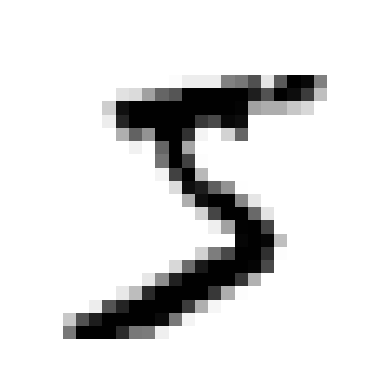

In [92]:
# looking at one of the shapes
import matplotlib.pyplot as plt
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [64]:
y[0]

'5'

In [67]:
# splitting the dataset
X_test, X_train, y_test, y_train = X[60000:], X[:60000], y[60000:], y[:60000]

# Training a Binary classifier


In [68]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [69]:
# using stochastic gradient descent because it is capable of handling very large dataset
from sklearn.linear_model import SGDClassifier
"""SGD deals with training instances independently, 
    one at a time, which also makes SGD well suited for online learning
"""
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [70]:
sgd_clf.predict([some_digit])

array([ True])

In [71]:
# Performance Measures
"""k-fold cross-validation means splitting the training set into k folds (in this case, three), 
then training the model k times, holding out a different fold each time for evaluation
"""
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [72]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train,y_train_5)
print(any(dummy_clf.predict(X_train)))
# no 5s detected

False


In [73]:
cross_val_score(dummy_clf,X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

In [74]:
# self cross-validation code
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
skfolds = StratifiedKFold(n_splits=3) # add_shuffle = True if the dataset is not already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_folds = X_train[test_index]
    y_test_folds = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_folds)
    n_correct = sum(y_pred == y_test_folds)
    print(n_correct / len(y_pred)) # prints accuracy of 0.95035, 0.96035, 0.9604

0.95035
0.96035
0.9604


# Confusion Matrices

In [75]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [76]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [77]:
y_train_perfection_pred = y_train_5
confusion_matrix(y_train_5, y_train_perfection_pred)

array([[54579,     0],
       [    0,  5421]])

In [78]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [79]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [80]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [81]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [82]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [83]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [84]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                            method="decision_function")

In [85]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

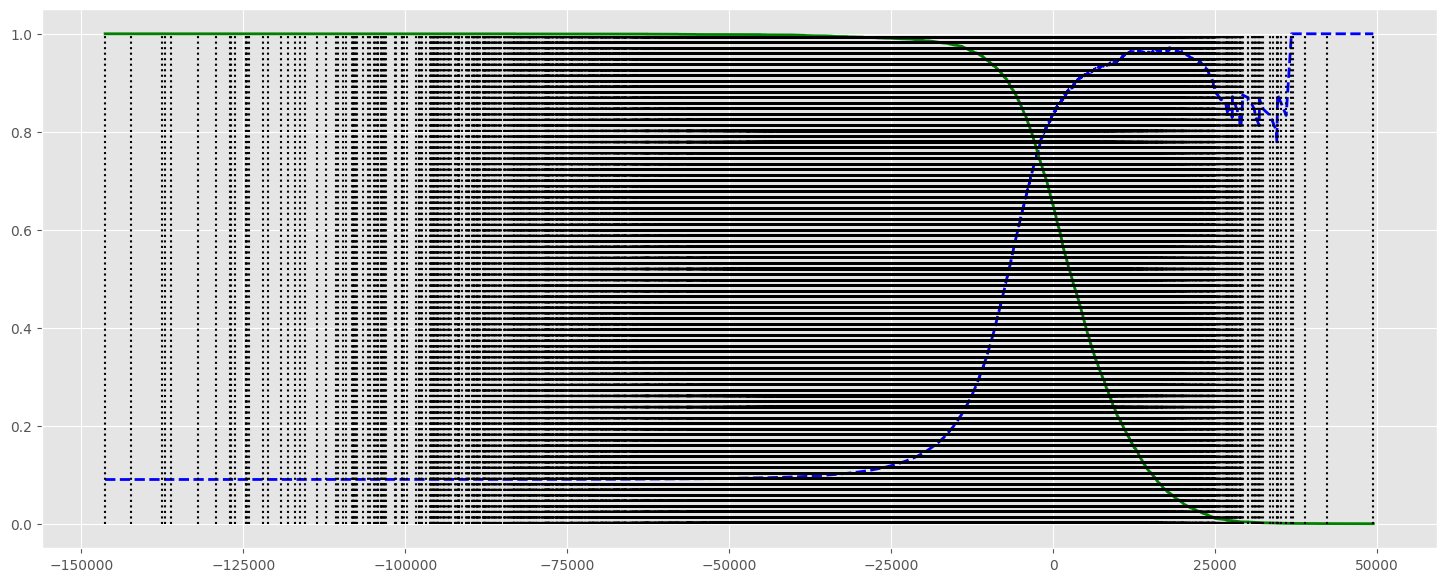

In [93]:
# plot the recall and precision as a threshold function
plt.figure(figsize=(18, 7))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2) 
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2) 
plt.vlines(thresholds, 0, 1.0, "k", "dotted", label="threshold")
plt.savefig("recall_precisions.png", dpi=300)
plt.show()

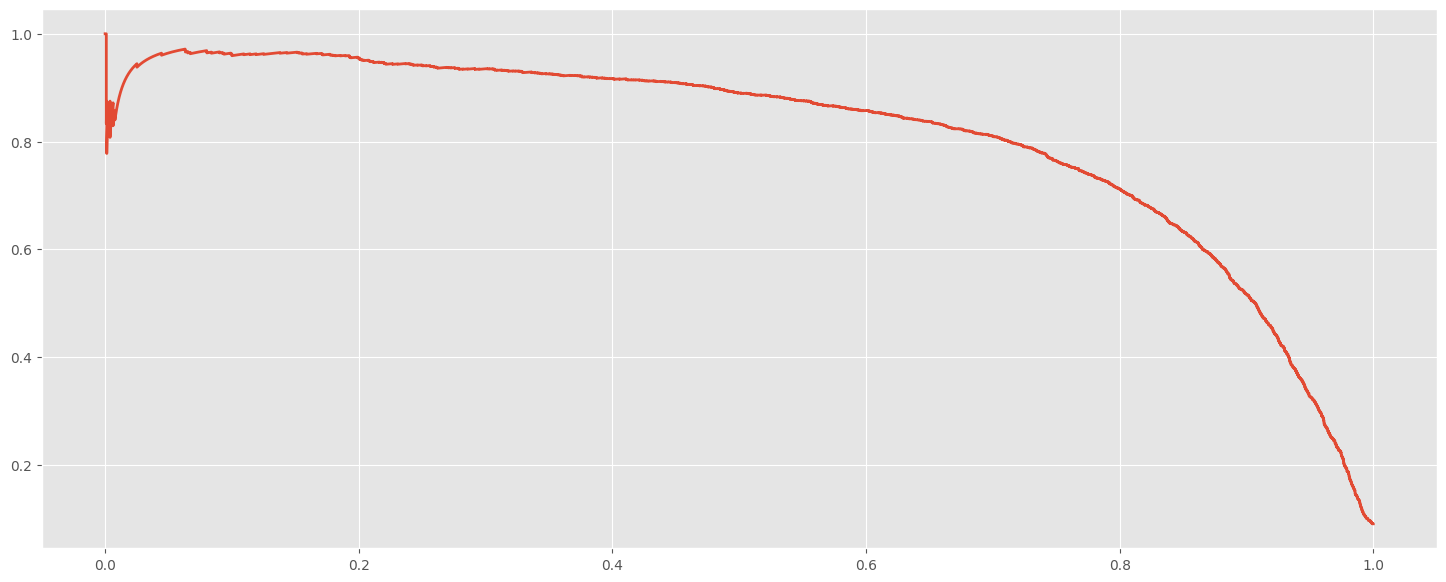

In [90]:
plt.style.use("ggplot")
plt.figure(figsize=(18,7))
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.show()

In [94]:
idx_for_90_precision = (precisions >= .90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

3370.0194991439557

In [95]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [96]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [97]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

# The ROC Curve
<h3>Receiver Operating Characteristics</h3>